# Groundwater Level Analysis using Python

This project analyzes groundwater datasets to understand trends,
regional variations, and environmental factors affecting groundwater levels.
The analysis uses Python data science libraries such as Pandas,
Matplotlib, and Seaborn.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set_style("whitegrid")

In [4]:
pip install kagglehub

In [5]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("ashokkonga/ground-water-analysis")

print("Path to dataset files:", path)

100%|██████████| 82.4k/82.4k [00:00<00:00, 162kB/s]

Extracting files...
Path to dataset files: C:\Users\USER\.cache\kagglehub\datasets\ashokkonga\ground-water-analysis\versions\1


In [6]:
import os

os.listdir(path)

['GW_2018 - Copy.csv', 'GW_2018.csv', 'GW_2019.csv']

In [19]:
import pandas as pd

df_2018 = pd.read_csv(path + "/GW_2018.csv")
df_2019 = pd.read_csv(path + "/GW_2019.csv")
df_2018["Year"] = 2018
df_2019["Year"] = 2019
df = pd.concat([df_2018, df_2019], ignore_index=True)

In [18]:
df.shape

(738, 38)

In [20]:
df.columns = df.columns.str.strip()
df.columns

Index(['sno', 'district', 'mandal', 'village', 'lat_gis', 'long_gis', 'gwl',
       'season', 'pH', 'E.C', 'TDS', 'CO3', 'HCO3', 'Cl', 'F', 'NO3', 'SO4',
       'Na', 'K', 'Ca', 'Mg', 'T.H', 'SAR', 'Classification', 'RSC  meq  / L',
       'Classification.1', 'Year', 'EC', 'CO_-2', 'HCO_ -', 'Cl -', 'F -',
       'NO3-', 'SO4-2', 'Na+', 'K+', 'Ca+2', 'Mg+2'],
      dtype='object')

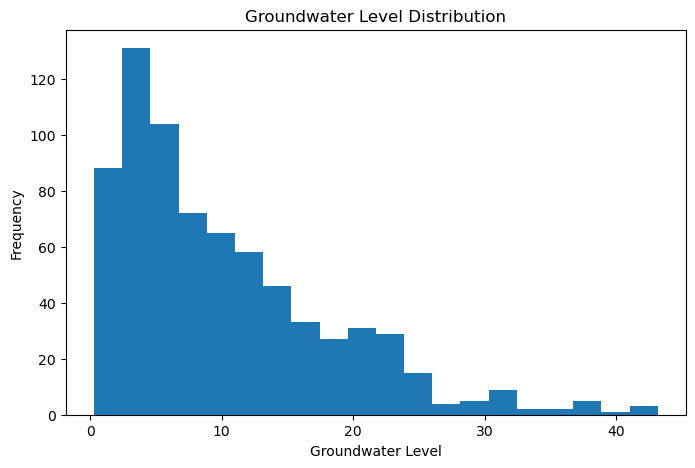

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["gwl"], bins=20)
plt.title("Groundwater Level Distribution")
plt.xlabel("Groundwater Level")
plt.ylabel("Frequency")
plt.show()

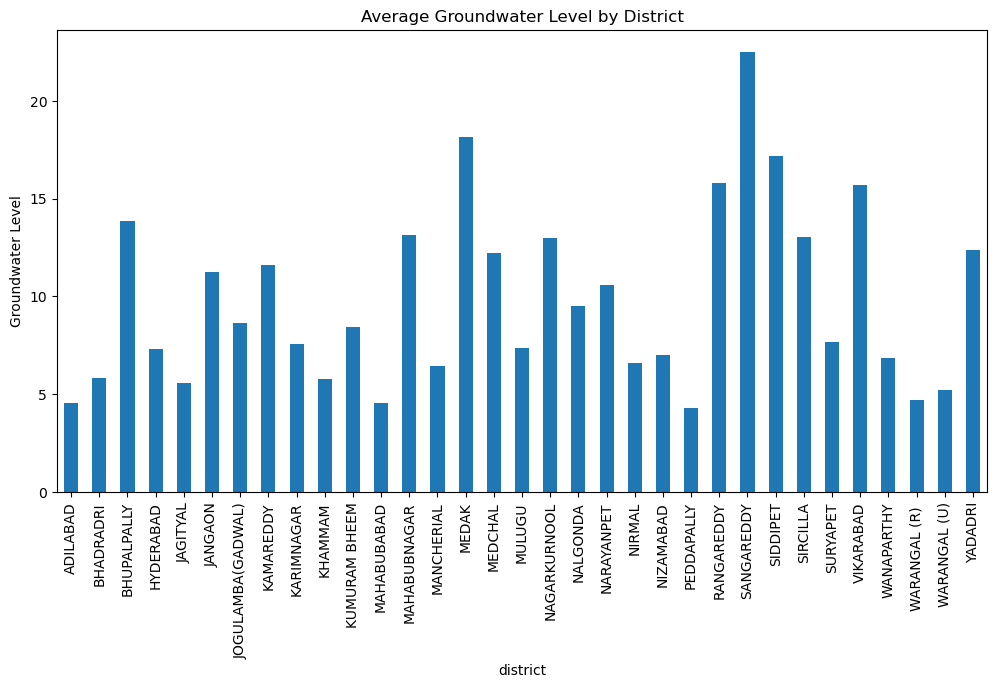

In [22]:
district_avg = df.groupby("district")["gwl"].mean()

district_avg.plot(kind="bar", figsize=(12,6))
plt.title("Average Groundwater Level by District")
plt.ylabel("Groundwater Level")
plt.show()

In [24]:
corr_matrix = df.corr(numeric_only=True)

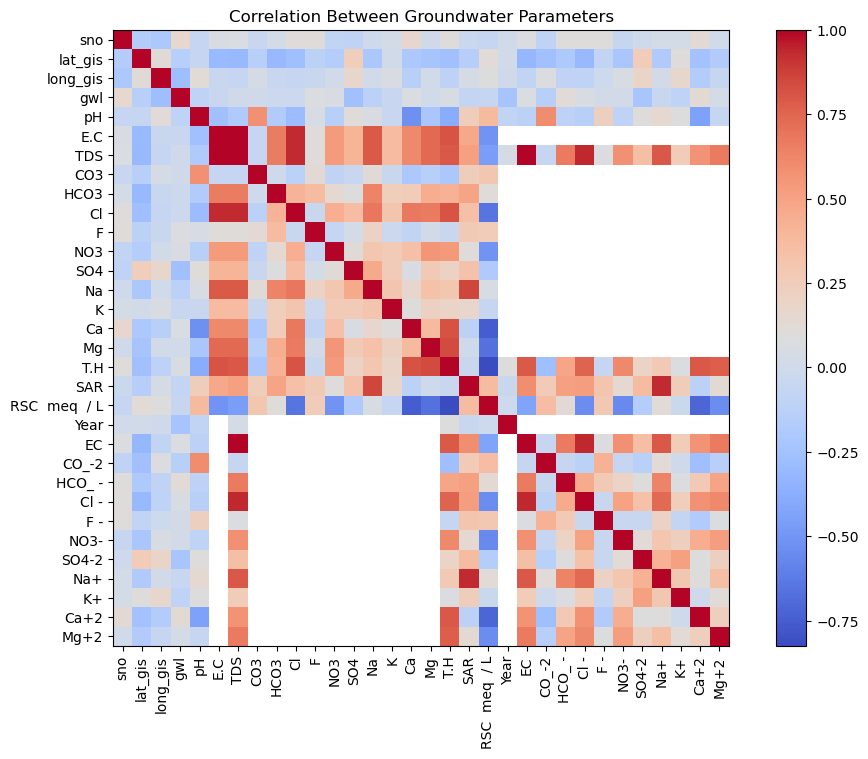

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plt.imshow(corr_matrix, cmap="coolwarm", interpolation="none")
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Between Groundwater Parameters")
plt.show()

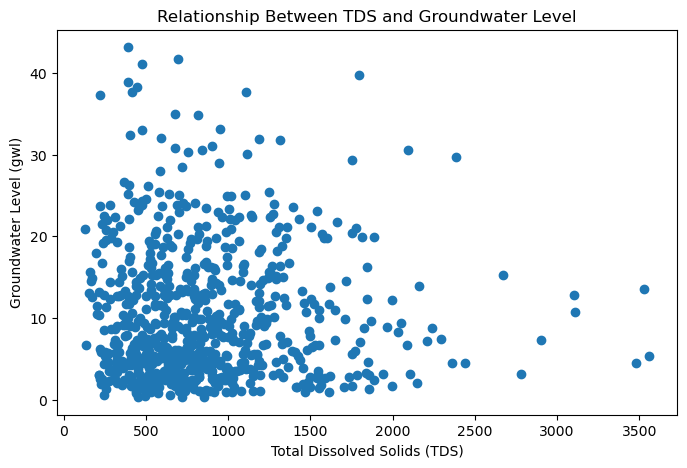

In [26]:
plt.figure(figsize=(8,5))
plt.scatter(df["TDS"], df["gwl"])

plt.xlabel("Total Dissolved Solids (TDS)")
plt.ylabel("Groundwater Level (gwl)")
plt.title("Relationship Between TDS and Groundwater Level")

plt.show()

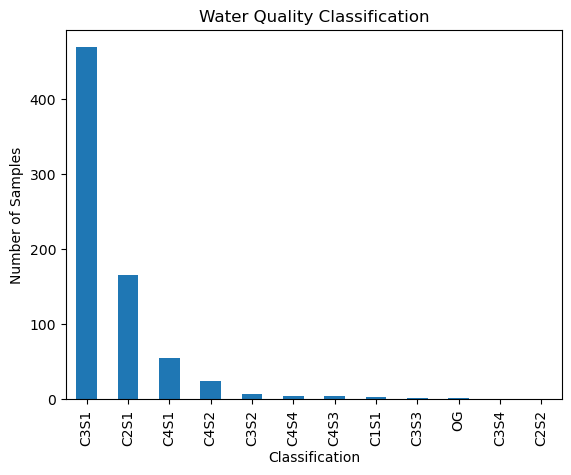

In [27]:
classification_counts = df["Classification"].value_counts()

classification_counts.plot(kind="bar")

plt.title("Water Quality Classification")
plt.xlabel("Classification")
plt.ylabel("Number of Samples")

plt.show()

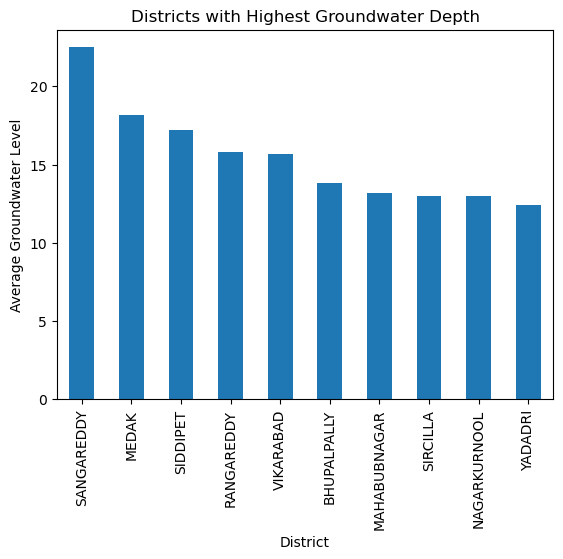

In [28]:
district_avg = df.groupby("district")["gwl"].mean()

district_avg_sorted = district_avg.sort_values(ascending=False)

district_avg_sorted.head(10).plot(kind="bar")

plt.title("Districts with Highest Groundwater Depth")
plt.xlabel("District")
plt.ylabel("Average Groundwater Level")
plt.show()

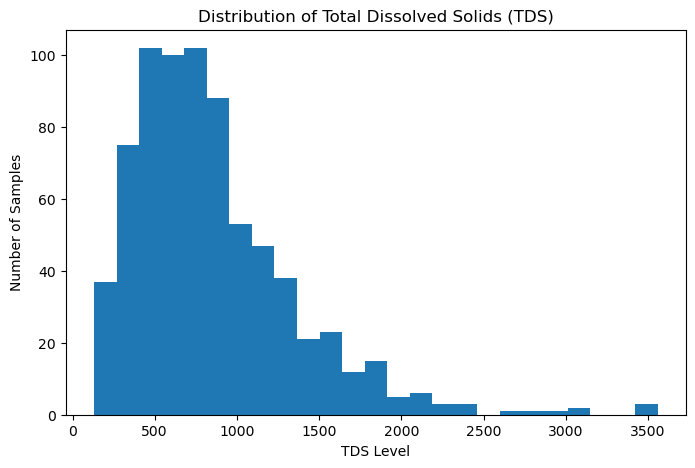

In [29]:
plt.figure(figsize=(8,5))
plt.hist(df["TDS"], bins=25)

plt.title("Distribution of Total Dissolved Solids (TDS)")
plt.xlabel("TDS Level")
plt.ylabel("Number of Samples")

plt.show()

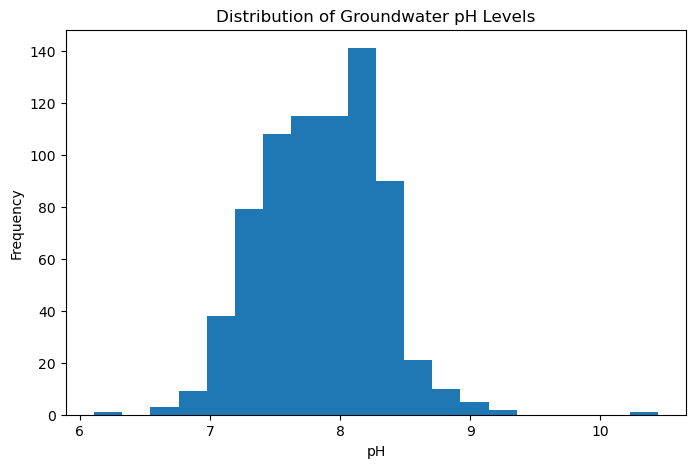

In [30]:
plt.figure(figsize=(8,5))
plt.hist(df["pH"], bins=20)

plt.title("Distribution of Groundwater pH Levels")
plt.xlabel("pH")
plt.ylabel("Frequency")

plt.show()

### Final Insights

1. Groundwater depth varies significantly between districts.
2. Several samples show high TDS levels, indicating potential water quality concerns.
3. pH values generally fall within acceptable ranges but vary across regions.
4. Chemical parameters show relationships that influence groundwater characteristics.
5. Machine learning models can be used to predict groundwater levels based on chemical composition.

### Conclusion

This project analyzed groundwater levels and hydrochemical parameters
using Python-based data analysis tools.

Exploratory analysis revealed regional variation in groundwater depth
and water quality parameters such as TDS and pH.

Such analyses can help identify areas facing groundwater stress
and support sustainable water resource management.